In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:

df_day = pd.read_csv(r"C:\Users\rishy\Downloads\aiml\day.csv")
df_hour = pd.read_csv(r"C:\Users\rishy\Downloads\ml\hour.csv")

print("Files Loaded Successfully!")
df_day.head(), df_hour.head()




Files Loaded Successfully!


(   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
 0        1  2011-01-01       1   0     1        0        6           0   
 1        2  2011-01-02       1   0     1        0        0           0   
 2        3  2011-01-03       1   0     1        0        1           1   
 3        4  2011-01-04       1   0     1        0        2           1   
 4        5  2011-01-05       1   0     1        0        3           1   
 
    weathersit      temp     atemp       hum  windspeed  casual  registered  \
 0           2  0.344167  0.363625  0.805833   0.160446     331         654   
 1           2  0.363478  0.353739  0.696087   0.248539     131         670   
 2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
 3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
 4           1  0.226957  0.229270  0.436957   0.186900      82        1518   
 
     cnt  
 0   985  
 1   801  
 2  1349  
 3  1562  
 4  1600  ,
    i

The "Id" variable doesn't provide any meaningful information for the data; it's equivalent to the index, so we'll drop this column.

In [3]:

def clean_data(df, name="dataset"):

    print("\n====================================================")
    print(f"CLEANING REPORT FOR: {name.upper()}")
    print("====================================================")

    duplicates = df.duplicated().sum()
    print("Duplicate rows found:", duplicates)
    df = df.drop_duplicates()

    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("[^a-z0-9_]", "", regex=True)
    )

    df = df.apply(lambda col: col.str.strip().str.lower() if col.dtype == "object" else col)

    if "dteday" in df.columns:
        df["dteday"] = pd.to_datetime(df["dteday"], errors="coerce")

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="ignore")

    nulls_before = df.isnull().sum().sum()
    print("Null values before cleaning:", nulls_before)

    df.fillna(df.mean(numeric_only=True), inplace=True)

    for col in df.select_dtypes(include="object").columns:
        if df[col].mode().size > 0:
            df[col] = df[col].mode()[0]

    nulls_after = df.isnull().sum().sum()
    print("Null values after cleaning:", nulls_after)

    return df





In [4]:

clean_day = clean_data(df_day, "Day Dataset")
clean_hour = clean_data(df_hour, "Hour Dataset")



CLEANING REPORT FOR: DAY DATASET
Duplicate rows found: 0
Null values before cleaning: 0
Null values after cleaning: 0

CLEANING REPORT FOR: HOUR DATASET
Duplicate rows found: 0
Null values before cleaning: 0
Null values after cleaning: 0


C:\Users\rishy\AppData\Local\Temp\ipykernel_11724\4045081770.py:24: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
C:\Users\rishy\AppData\Local\Temp\ipykernel_11724\4045081770.py:24: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [5]:
def drop_columns(df, name="dataset"):
    cols_to_drop = ["instant", "dteday", "yr", "casual", "registered"]

    print("\nColumns before drop:", df.columns.tolist())
    dropped = [col for col in cols_to_drop if col in df.columns]
    print("Dropping columns:", dropped)

    df = df.drop(columns=dropped, errors="ignore")
    print("Columns after drop:", df.columns.tolist())

    return df



In [6]:
clean_day = drop_columns(clean_day, "Day Dataset")
clean_hour = drop_columns(clean_hour, "Hour Dataset")



Columns before drop: ['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
Dropping columns: ['instant', 'dteday', 'yr', 'casual', 'registered']
Columns after drop: ['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']

Columns before drop: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
Dropping columns: ['instant', 'dteday', 'yr', 'casual', 'registered']
Columns after drop: ['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


In [7]:
def remove_outliers(df, name="dataset"):
    print(f"\nChecking outliers in {name} ...")

    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
    total_outliers = 0
    df_clean = df.copy()

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        total_outliers += outliers

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    print("Total outliers removed:", total_outliers)
    return df_clean


In [8]:
clean_day = remove_outliers(clean_day, "Day Dataset")
clean_hour = remove_outliers(clean_hour, "Hour Dataset")



Checking outliers in Day Dataset ...
Total outliers removed: 36

Checking outliers in Hour Dataset ...
Total outliers removed: 1372


In [9]:
clean_day.to_csv("cleaned_day.csv", index=False)
clean_hour.to_csv("cleaned_hour.csv", index=False)

print("Cleaned files saved successfully.")


Cleaned files saved successfully.


In [10]:
def eda_summary(df, name="dataset"):
    print("\n====================================================")
    print(f"EDA SUMMARY FOR: {name.upper()}")
    print("====================================================")

    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicate Rows:", df.duplicated().sum())
    print("\nData Types:\n", df.dtypes)

    print("\nStatistical Summary:")
    print(df.describe(include='all').T)

    plt.figure(figsize=(6, 3))
    df.isnull().sum().plot(kind='bar')
    plt.title(f"Missing Values in {name}")
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
    plt.title(f"Correlation Heatmap - {name}")
    plt.show()

    if "cnt" in df.columns:
        plt.figure(figsize=(6, 3))
        sns.histplot(df["cnt"], kde=True)
        plt.title(f"{name} - Distribution of cnt")
        plt.show()



EDA SUMMARY FOR: DAY DATASET
Shape: (696, 11)

Columns: ['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']

Missing Values:
 season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

Duplicate Rows: 0

Data Types:
 season          int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
cnt             int64
dtype: object

Statistical Summary:
            count         mean          std        min          25%  \
season      696.0     2.515805     1.101879   1.000000     2.000000   
mnth        696.0     6.551724     3.422763   1.000000     4.000000   
holiday     696.0     0.000000     0.000000   0.000000     0.000000   
weekday     696.0     3.0316

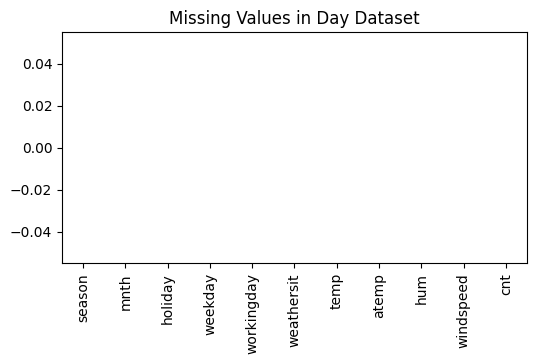

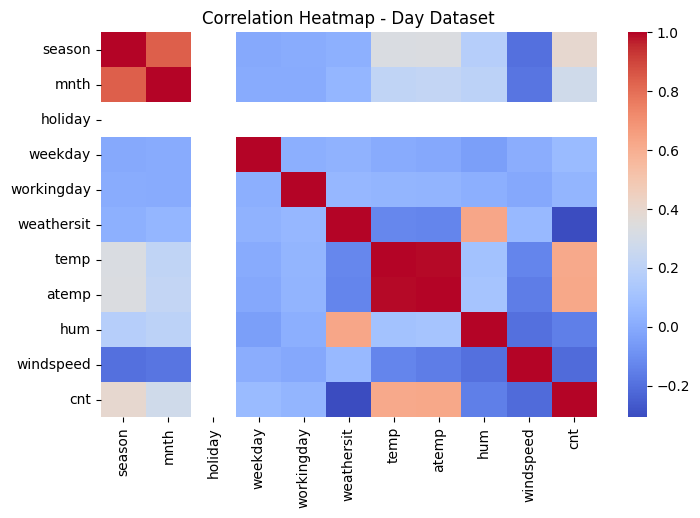

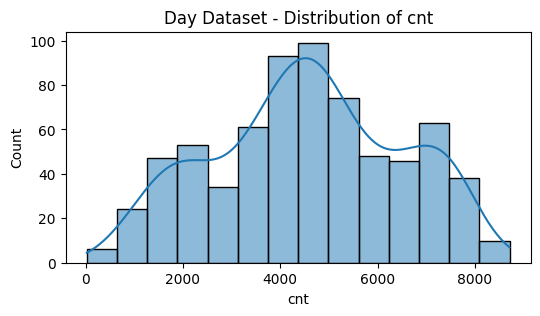


EDA SUMMARY FOR: HOUR DATASET
Shape: (16029, 12)

Columns: ['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']

Missing Values:
 season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

Duplicate Rows: 2

Data Types:
 season          int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
cnt             int64
dtype: object

Statistical Summary:
              count        mean         std   min      25%       50%  \
season      16029.0    2.507767    1.104878  1.00   2.0000    3.0000   
mnth        16029.0    6.540146    3.435285  1.00   4.0000    7.0000   
hr          16029.0   11.410756    6.981685  0.00

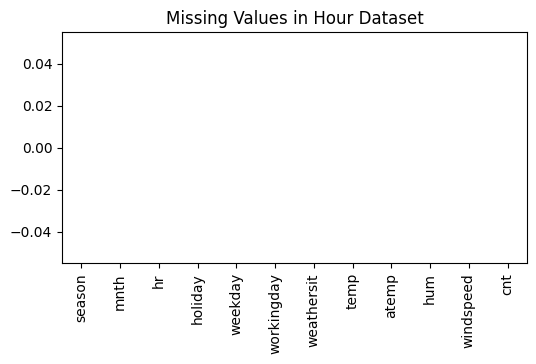

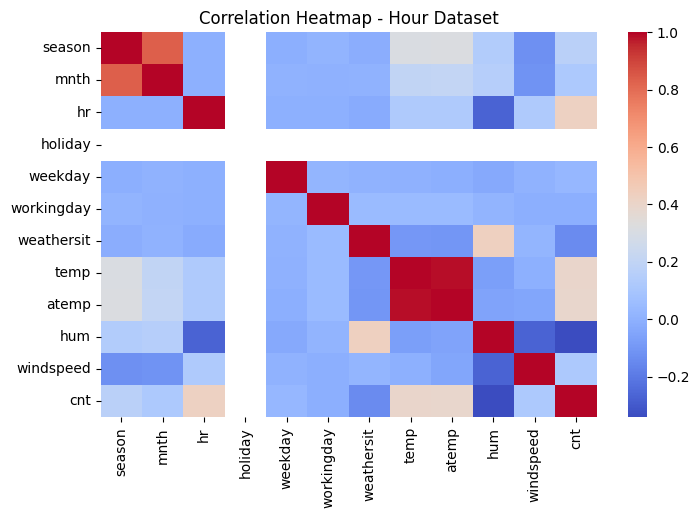

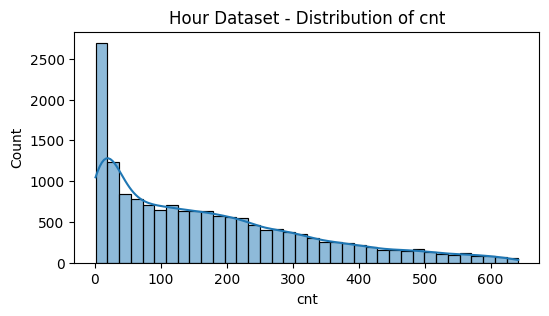


EDA Completed Successfully!


In [11]:
eda_summary(clean_day, "Day Dataset")
eda_summary(clean_hour, "Hour Dataset")

print("\nEDA Completed Successfully!")
